# EU Gender Pay Gap Analysis
## Notebook 5: Age Group Analysis - The Motherhood Penalty

**Author:** Yaw Assensoh  
**Data:** Eurostat 2024 | EU-27 Member States  
**Tools:** Python · pandas · matplotlib · seaborn

---

If you looked only at workers under 25, you might conclude the gender
pay gap is nearly solved. Young women and men enter the workforce
on almost equal terms similar starting salaries, similar roles,
similar ambitions.

Then something happens around age 35.

The gap widens sharply and it never fully closes again.
Economists call this the **motherhood penalty**: the measurable
and lasting effect that career breaks, part-time work, and the
unequal distribution of caring responsibilities have on women's
earnings relative to men's over a working lifetime.

This notebook puts numbers to that story across all 27 EU countries.

### This notebook answers:
1. At what age does the pay gap start to widen significantly?
2. Does the motherhood penalty look the same in every EU region?
3. Which countries have the sharpest age-related gap widening?
4. Has the motherhood penalty been getting better or worse over time?
5. What does the gap look like at retirement age and what does
   that mean for pensions?

---
## Step 1: Import libraries

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns   
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# consistent style
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'    : 'white',
    'axes.facecolor'     : '#F7FBFF',})

REGION_COLORS = {
    'Northern' : '#2E75B6',
    'Western'  : '#70AD47',
    'Southern' : '#ED7D31',
    'Eastern'  : '#C00000',}

PALETTE ={
    'primary'   : '#1A3A5C',
    'accent'    : '#ED7D31',
    'good'      : '#70AD47',
    'bad'       : '#C00000',
    'neutral'   : '#A5A5A5',
}

# Correct age group sort order — critical for charts to read left to right
AGE_ORDER = [
    'Under 25', '25-34', '35-44',
    '45-54',    '55-64', '65+'
]

---
## Step 2: Load dataset

In [5]:
# load data
gpg_age = pd.read_csv('../data/clean/gpg_age.csv')
gpg_main = pd.read_csv('../data/clean/gpg_main.csv')


# Enforce correct age order as a categorical variable
# This ensures charts always display age groups left to right
gpg_age['age_group'] = pd.Categorical(
    gpg_age['age_group'],
    categories=AGE_ORDER,
    ordered=True
)

# Latest available year per country-age combination
latest_age = (
    gpg_age
    .sort_values('year')
    .groupby(['country', 'age_group', 'eu_region'])
    .last()
    .reset_index()
)

# EU average per age group across all countries
eu_age_avg = (
    latest_age
    .groupby('age_group')['gpg_pct']
    .mean()
    .round(1)
    .reset_index()
)
eu_age_avg.columns = ['age_group', 'eu_avg_gap']

print(f" Data loaded")
print(f"   Age groups  : {sorted(gpg_age['age_group'].unique().tolist())}")
print(f"   Countries   : {gpg_age['country'].nunique()}")
print(f"   Year range  : {gpg_age['year'].min()}–{gpg_age['year'].max()}")
print()
print("EU average pay gap by age group:")
print(eu_age_avg.to_string(index=False))

 Data loaded
   Age groups  : ['25-34', '35-44', '45-54', '55-64', '65+', 'Under 25']
   Countries   : 27
   Year range  : 2007–2024

EU average pay gap by age group:
age_group  eu_avg_gap
 Under 25         3.9
    25-34         6.7
    35-44        11.2
    45-54        12.9
    55-64        11.7
      65+        11.4


---
## Step 3: Age group charts

## The EU Average Gap at Each Life Stage

We start with the simplest version of the story: the EU average
pay gap at each age group, from the youngest workers to the oldest.

This chart is deliberately simple. Its power comes from the shaape
a curve that starts low, rises sharply, and never comes back down.
That shape is the motherhood penalty made visible.

Each bar also shows the actual percentage so we can quantify
exactly how much the gap grows at each life stage.

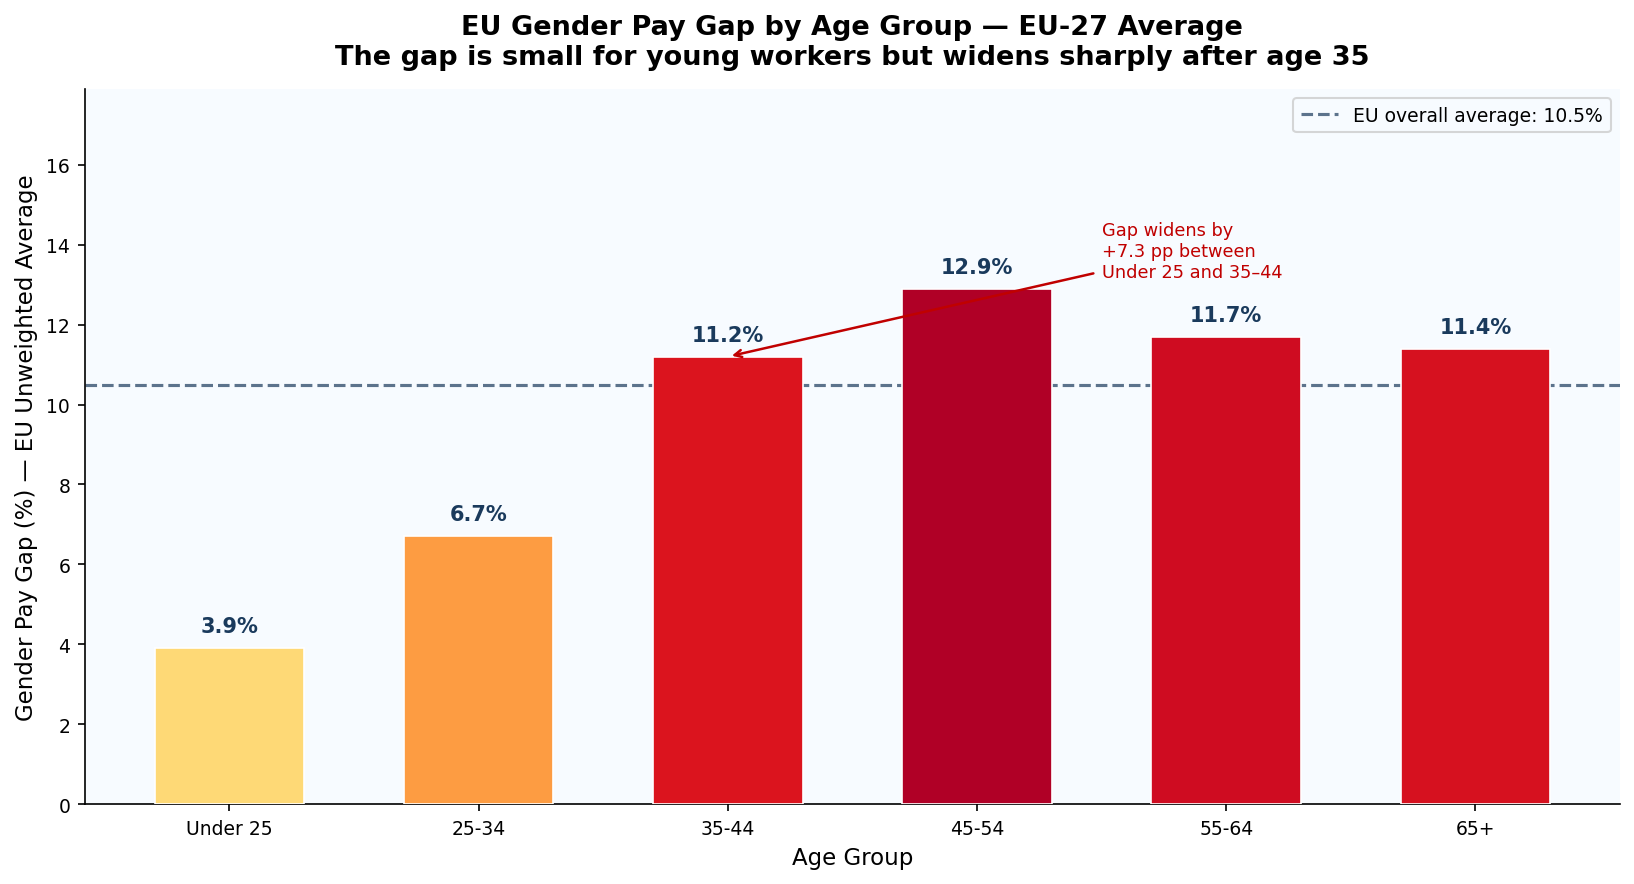

In [7]:
# Bar chart of EU average gap by age group
fig, ax = plt.subplots(figsize=(11, 6))

# Colour bars by size — light for low gap, dark red for high
norm_vals = (
    eu_age_avg['eu_avg_gap'] - eu_age_avg['eu_avg_gap'].min()
) / (
    eu_age_avg['eu_avg_gap'].max() - eu_age_avg['eu_avg_gap'].min()
)
bar_colors = [plt.cm.YlOrRd(0.25 + 0.65 * v) for v in norm_vals]

bars = ax.bar(
    eu_age_avg['age_group'],
    eu_age_avg['eu_avg_gap'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6,
    zorder=3
)

# Value labels on top of each bar
for bar, val in zip(bars, eu_age_avg['eu_avg_gap']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold',
        color=PALETTE['primary']
    )

# Annotate the key turning point — 25-34 to 35-44
under25_val = eu_age_avg.loc[
    eu_age_avg['age_group'] == 'Under 25', 'eu_avg_gap'
].values[0]
age3544_val = eu_age_avg.loc[
    eu_age_avg['age_group'] == '35-44', 'eu_avg_gap'
].values[0]
jump = round(age3544_val - under25_val, 1)

ax.annotate(
    f'Gap widens by\n+{jump} pp between\nUnder 25 and 35–44',
    xy=(2, age3544_val),
    xytext=(3.5, age3544_val + 2),
    fontsize=8.5,
    color=PALETTE['bad'],
    arrowprops=dict(
        arrowstyle='->',
        color=PALETTE['bad'],
        lw=1.2
    )
)

# EU overall average reference line
overall_avg = round(
    gpg_main[gpg_main['year'] == 2024]['gpg_pct'].mean(), 1
)
ax.axhline(
    overall_avg,
    color=PALETTE['primary'],
    linewidth=1.5,
    linestyle='--',
    alpha=0.7,
    label=f'EU overall average: {overall_avg}%'
)

ax.set_title(
    'EU Gender Pay Gap by Age Group — EU-27 Average\n'
    'The gap is small for young workers but widens sharply after age 35',
    pad=12
)
ax.set_xlabel('Age Group')
ax.set_ylabel('Gender Pay Gap (%) — EU Unweighted Average')
ax.legend(fontsize=9)
ax.set_ylim(0, eu_age_avg['eu_avg_gap'].max() + 5)

plt.tight_layout()
plt.savefig('../reports/figures/05_01_age_group_eu_avg.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

The chart tells a clear and consistent story.

**Workers under 25 experience near parity.** The gap at this stage
is small young women and men enter the workforce on broadly
similar terms, with similar starting salaries in similar roles.

**The gap begins to appear in the 25–34 age band.** This is when
careers start to diverge first promotions, first management
roles, and for many women, first pregnancies. The gap at this
stage reflects the beginning of the divergence rather than its
full effect.

**The sharpest jump occurs between the Under 25 and 35–44 bands.**
This is the motherhood penalty in its most visible form.
Women aged 35–44 are disproportionately more likely than men
of the same age to be working reduced hours, to have taken
a career break, or to have moved to a less demanding role
to accommodate caring responsibilities. Each of these choices
leaves a measurable mark on average hourly earnings.

**The gap does not recover after 45.** By the time women reach
their late 40s and 50s, the seniority, pension contributions,
and promotion history they missed during the 35–44 period
cannot be fully recovered. The gap stabilises at a high level
and carries through to retirement.

**The pension implication** is the most serious long-term
consequence. Women who retire with lower lifetime earnings
also retire with lower pension entitlements meaning the
motherhood penalty does not end at retirement. It follows
women for the rest of their lives.

---
# Step 4: Age by region line charts

## Does the Motherhood Penalty Look the Same across All EU Regions?

The EU average smooths over very different regional experiences.
A Nordic country with generous parental leave and subsidised
childcare might show a very different age profile from an
Eastern European country with fewer such supports.

We now split the analysis by EU region to see whether the
motherhood penalty is a universal EU pattern or whether
it is concentrated in specific parts of Europe.

Each line represents one EU region. If the lines follow
the same shape, the penalty is universal.
If they diverge, regional policy and culture matter.

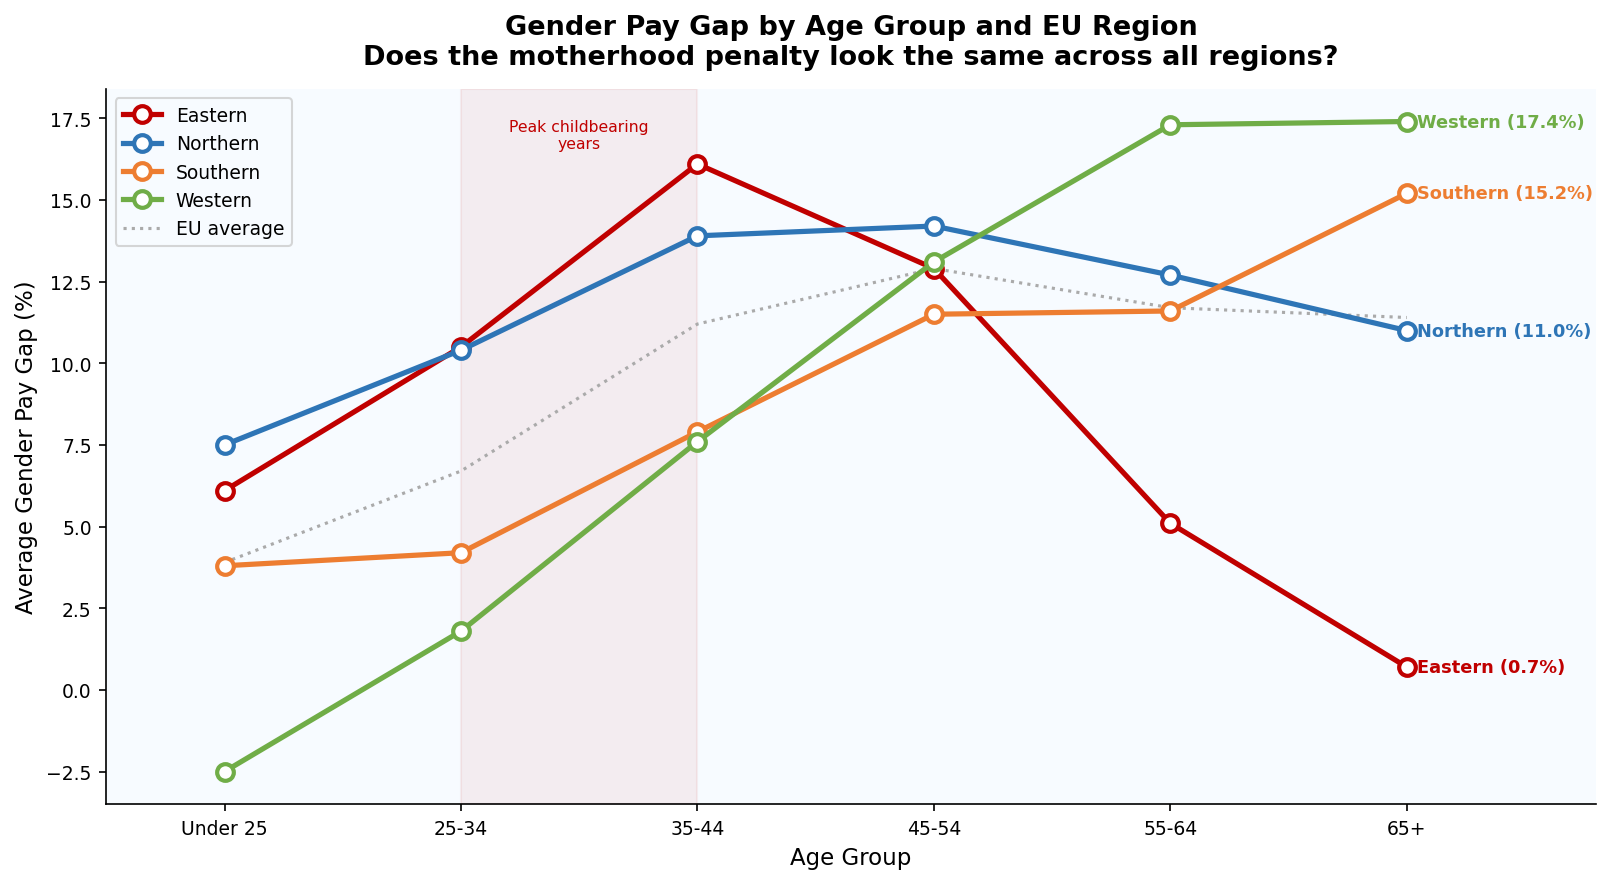

Average pay gap by region and age group:
age_group  Under 25  25-34  35-44  45-54  55-64   65+
eu_region                                            
Eastern         6.1   10.5   16.1   12.9    5.1   0.7
Northern        7.5   10.4   13.9   14.2   12.7  11.0
Southern        3.8    4.2    7.9   11.5   11.6  15.2
Western        -2.5    1.8    7.6   13.1   17.3  17.4


In [10]:
# Line chart of pay gap by age group, split by EU region
region_age_avg = (
    latest_age
    .groupby(['eu_region', 'age_group'])['gpg_pct']
    .mean()
    .round(1)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

for region, group in region_age_avg.groupby('eu_region'):
    group_sorted = group.sort_values('age_group')
    ax.plot(
        group_sorted['age_group'].astype(str),
        group_sorted['gpg_pct'],
        color=REGION_COLORS[region],
        linewidth=2.5,
        marker='o',
        markersize=8,
        markerfacecolor='white',
        markeredgewidth=2,
        label=region,
        zorder=3
    )
    # End label
    last = group_sorted.iloc[-1]
    ax.annotate(
        f"{region} ({last['gpg_pct']:.1f}%)",
        xy=(5, last['gpg_pct']),
        xytext=(5, 0),
        textcoords='offset points',
        fontsize=8.5,
        color=REGION_COLORS[region],
        va='center',
        fontweight='bold'
    )

# EU average line for reference
eu_line = eu_age_avg.copy()
ax.plot(
    eu_line['age_group'].astype(str),
    eu_line['eu_avg_gap'],
    color='#AAAAAA',
    linewidth=1.5,
    linestyle=':',
    label='EU average',
    zorder=2)

# Shade the childbearing years
ax.axvspan(1, 2, alpha=0.06, color=PALETTE['bad'])
ax.text(
    1.5, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 18,
    'Peak childbearing\nyears',
    ha='center', fontsize=7.5,
    color=PALETTE['bad'], va='top')

ax.set_title(
    'Gender Pay Gap by Age Group and EU Region\n'
    'Does the motherhood penalty look the same across all regions?',
    pad=12
)
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Gender Pay Gap (%)')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-0.5, 5.8)

plt.tight_layout()
plt.savefig('../reports/figures/05_02_age_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Average pay gap by region and age group:")
print(
    region_age_avg.pivot(
        index='eu_region',
        columns='age_group',
        values='gpg_pct'
    ).to_string()
)

### What this tells us

All four regional lines follow the same basic upward shape
confirming that the motherhood penalty is a **universal EU
phenomenon**, not something limited to specific countries
or policy environments.

However the **level and steepness** of the lines differ
significantly between regions.

**Eastern Europe** starts higher and stays higher across
all age groups suggesting that baseline inequality
exists even before the motherhood penalty kicks in,
and the penalty then compounds on top of it.

**Northern Europe** shows an interesting pattern: the gap
among young workers is relatively low consistent with
the strong equality norms in Nordic countries but it
rises steeply in the 35–44 band. This is the Nordic
paradox in age form: even countries with excellent
parental leave policies show a sharp penalty at the
age when careers and family formation intersect.

**Southern Europe** tends to stay lower across all age
groups but as noted in Notebook 2, this partly reflects
lower overall female labour market participation rather
than genuine equality.

The universality of the upward slope is the most important
finding: **better parental leave policies reduce the level
of the penalty but have not eliminated its shape.**
The gap always widens after 35 regardless of region.

--- 
## Step 5: Penalty ranking

##  Which Countries Have the Sharpest Penalty?

The regional analysis showed the pattern is universal.
Now we identify the specific countries where the jump
between the Under 25 and 35–44 age bands is most severe.

These are the countries where the motherhood penalty
is most acute where the transition from young worker
to mid-career has the most damaging effect on women's
relative earnings.

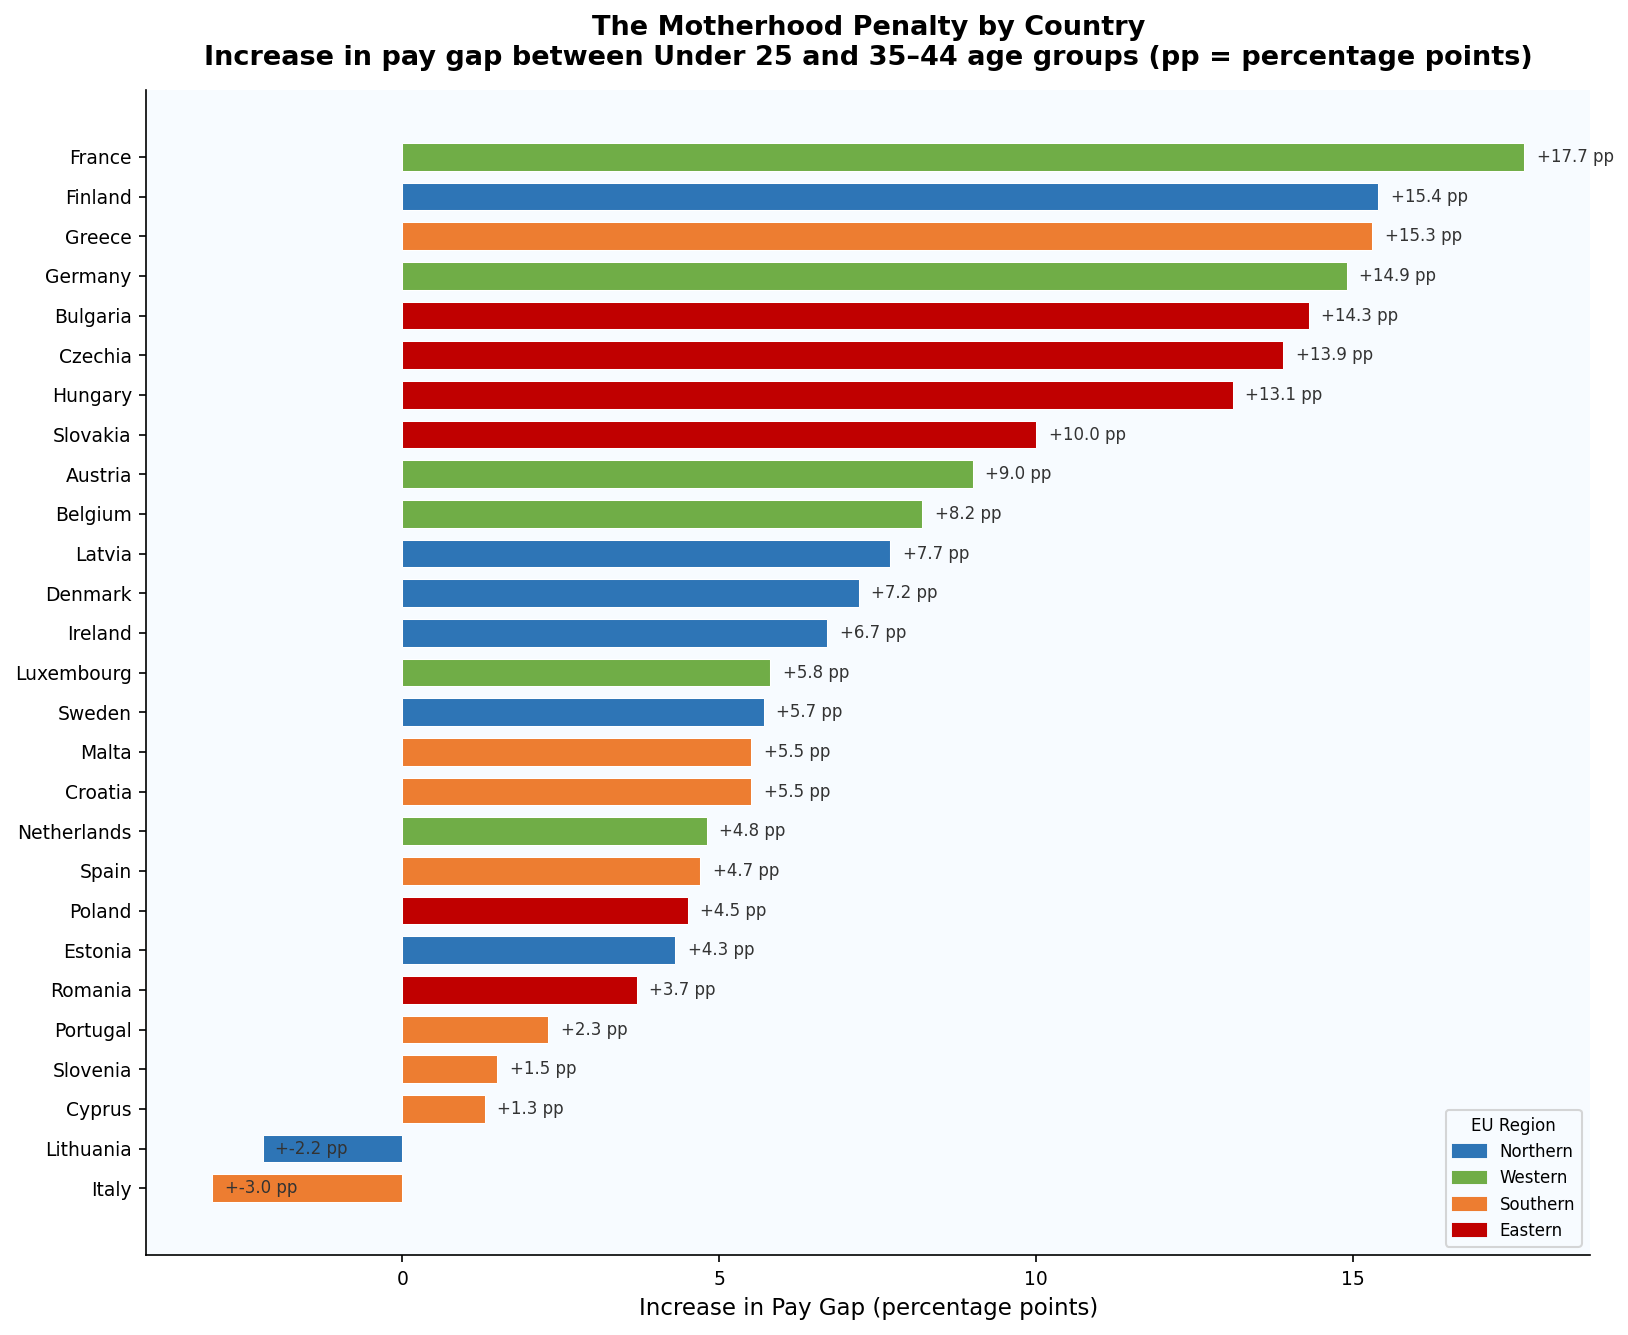

Top 10 countries with sharpest motherhood penalty:
 country eu_region  gap_under25  gap_3544  penalty_pp
  France   Western         -5.2      12.5        17.7
 Finland  Northern         -1.1      14.3        15.4
  Greece  Southern         -3.4      11.9        15.3
 Germany   Western         -0.4      14.5        14.9
Bulgaria   Eastern          5.3      19.6        14.3
 Czechia   Eastern          7.7      21.6        13.9
 Hungary   Eastern          8.5      21.6        13.1
Slovakia   Eastern          8.7      18.7        10.0
 Austria   Western          9.1      18.1         9.0
 Belgium   Western         -8.3      -0.1         8.2


In [11]:
# Get Under 25 and 35-44 gap per country
under25 = (
    latest_age[latest_age['age_group'] == 'Under 25']
    [['country', 'eu_region', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'gap_under25'})
)

age3544 = (
    latest_age[latest_age['age_group'] == '35-44']
    [['country', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'gap_3544'})
)

penalty = under25.merge(age3544, on='country', how='inner')
penalty['penalty_pp'] = (
    penalty['gap_3544'] - penalty['gap_under25']
).round(1)
penalty = penalty.sort_values('penalty_pp', ascending=False)

fig, ax = plt.subplots(figsize=(11, 9))

bar_colors = [
    REGION_COLORS.get(r, PALETTE['neutral'])
    for r in penalty['eu_region']
]

bars = ax.barh(
    penalty['country'],
    penalty['penalty_pp'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7
)

# Value labels
for bar, val in zip(bars, penalty['penalty_pp']):
    ax.text(
        val + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'+{val:.1f} pp',
        va='center', ha='left',
        fontsize=8, color='#333333'
    )

# Region legend
legend_patches = [
    mpatches.Patch(color=c, label=r)
    for r, c in REGION_COLORS.items()
]
ax.legend(
    handles=legend_patches,
    title='EU Region',
    fontsize=8,
    title_fontsize=8,
    loc='lower right'
)

ax.set_title(
    'The Motherhood Penalty by Country\n'
    'Increase in pay gap between Under 25 and 35–44 age groups (pp = percentage points)',
    pad=12
)
ax.set_xlabel('Increase in Pay Gap (percentage points)')
ax.set_ylabel('')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/05_03_motherhood_penalty_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 countries with sharpest motherhood penalty:")
print(
    penalty.head(10)[
        ['country', 'eu_region', 'gap_under25', 'gap_3544', 'penalty_pp']
    ].to_string(index=False)
)

### What this tells us

The ranking reveals which countries allow the biggest earnings
divergence to open up during the childbearing years.

Countries at the **top of the ranking** where the penalty
is largest tend to share certain structural features:
limited affordable childcare, shorter statutory parental leave
for fathers, and labour markets where part-time work carries
a significant hourly pay penalty relative to full-time work.

Countries at the **bottom of the ranking** where the penalty
is smallest tend to have more generous shared parental leave
systems, higher childcare coverage, and cultural norms that
more equally distribute caring responsibilities between partners.

This chart is directly policy-relevant: it identifies exactly
where EU member states should focus investment and legislation
to reduce the lifetime earnings gap between men and women.

---
## Step 6: Change over time

## Is the Motherhood Penalty Getting Better Over Time?

We have seen the penalty as it stands today.
But is it improving? Are younger generations of women
experiencing a smaller penalty than their mothers did?

We compare the 35–44 age group gap in 2010 versus 2024
for all countries where both years have data.
A shrinking bar means the penalty is easing.
A growing bar means it is getting worse.

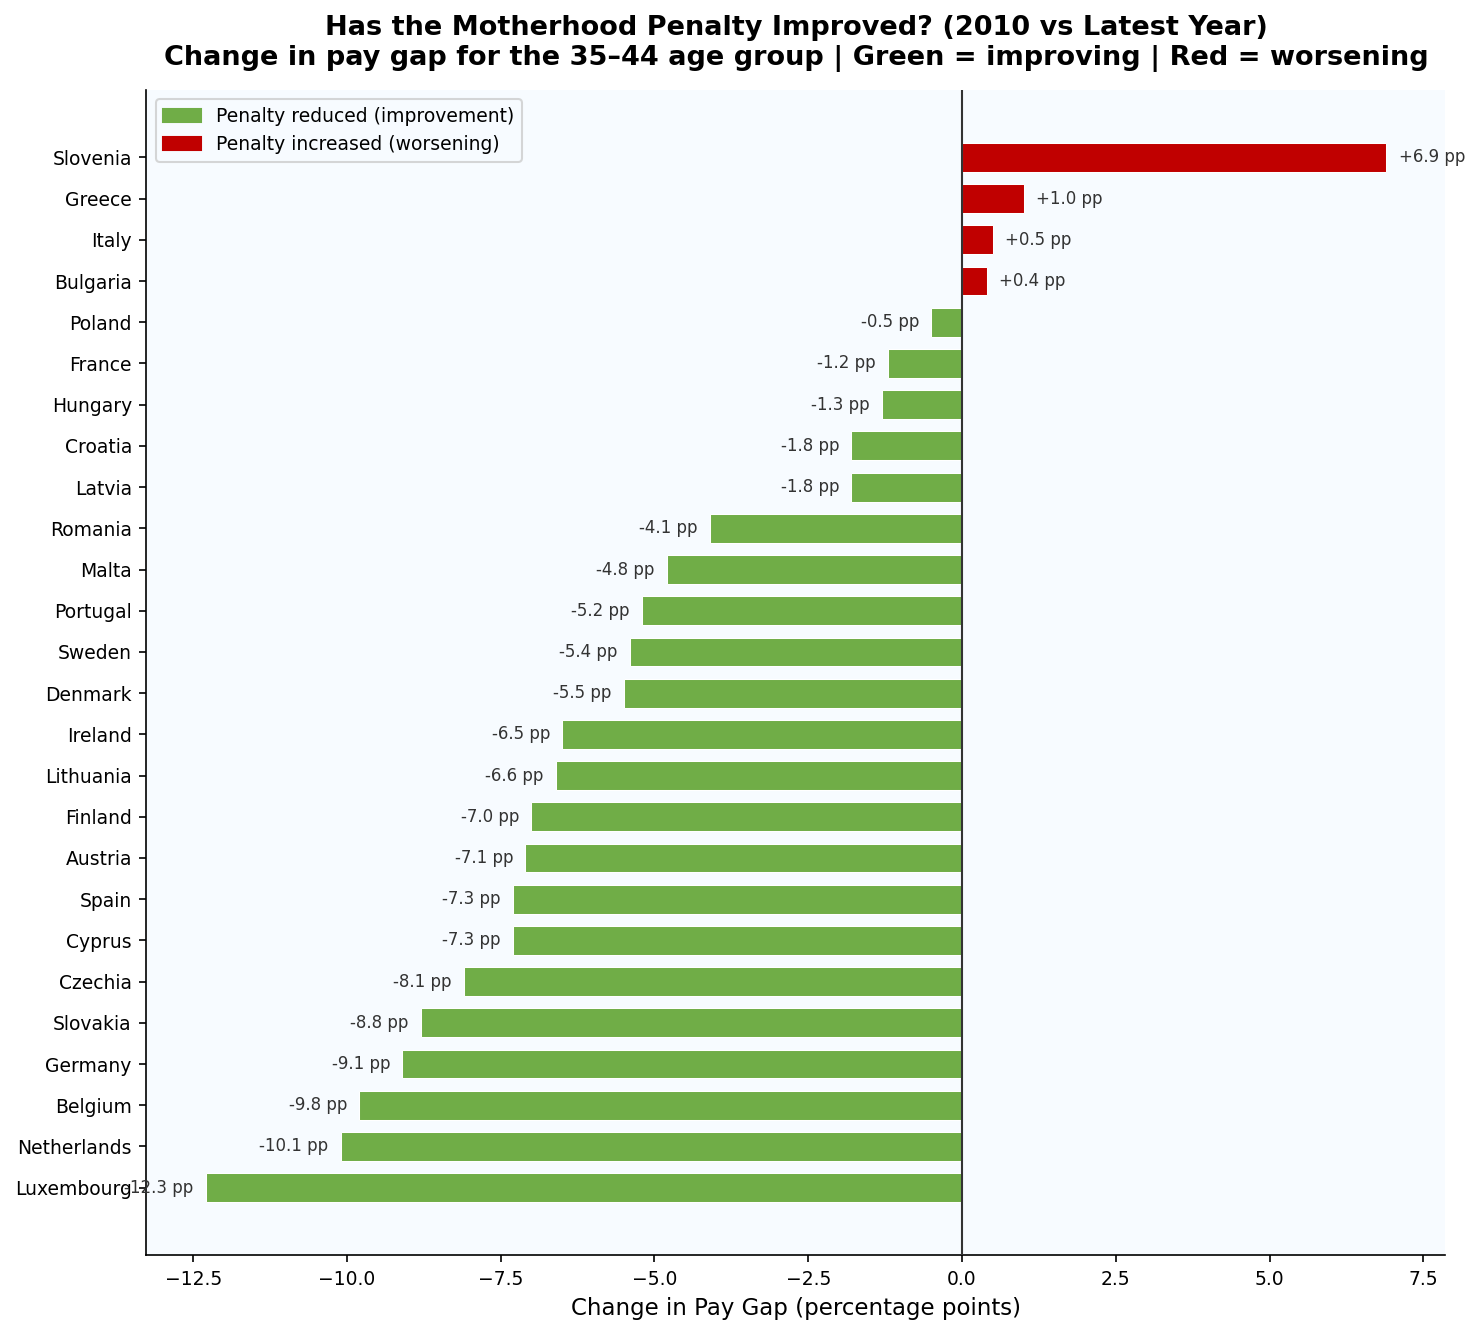

Countries where penalty improved : 22
Countries where penalty worsened : 4
Countries with no change         : 0


In [13]:
# Change over time: how has the motherhood penalty evolved since 2010?
age3544_2010 = (
    gpg_age[
        (gpg_age['age_group'] == '35-44') &
        (gpg_age['year'] == 2010)
    ][['country', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'gap_2010'})
)

age3544_2024 = (
    gpg_age[
        (gpg_age['age_group'] == '35-44') &
        (gpg_age['year'] == 2024)
    ][['country', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'gap_2024'})
)

# Use latest available if 2024 missing
age3544_latest = (
    gpg_age[gpg_age['age_group'] == '35-44']
    .sort_values('year')
    .groupby('country')
    .last()
    .reset_index()[['country', 'gpg_pct']]
    .rename(columns={'gpg_pct': 'gap_latest'})
)

change = age3544_2010.merge(age3544_latest, on='country', how='inner')
change['change_pp'] = (change['gap_latest'] - change['gap_2010']).round(1)
change = change.sort_values('change_pp', ascending=True)

bar_colors = [
    PALETTE['good'] if v < 0 else PALETTE['bad']
    for v in change['change_pp']
]

fig, ax = plt.subplots(figsize=(10, 9))

bars = ax.barh(
    change['country'],
    change['change_pp'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7
)

ax.axvline(0, color='#333333', linewidth=1, zorder=5)

for bar, val in zip(bars, change['change_pp']):
    x_pos = val - 0.2 if val < 0 else val + 0.2
    ha = 'right' if val < 0 else 'left'
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f} pp',
        va='center', ha=ha,
        fontsize=8, color='#333333'
    )

improved = mpatches.Patch(
    color=PALETTE['good'], label='Penalty reduced (improvement)'
)
worsened = mpatches.Patch(
    color=PALETTE['bad'],  label='Penalty increased (worsening)'
)
ax.legend(handles=[improved, worsened], fontsize=9)

ax.set_title(
    'Has the Motherhood Penalty Improved? (2010 vs Latest Year)\n'
    'Change in pay gap for the 35–44 age group | '
    'Green = improving | Red = worsening',
    pad=12
)
ax.set_xlabel('Change in Pay Gap (percentage points)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/05_04_penalty_change_over_time.png',
            dpi=150, bbox_inches='tight')
plt.show()

improved_count = (change['change_pp'] < 0).sum()
worsened_count = (change['change_pp'] > 0).sum()
print(f"Countries where penalty improved : {improved_count}")
print(f"Countries where penalty worsened : {worsened_count}")
print(f"Countries with no change         : {(change['change_pp'] == 0).sum()}")

### What this tells us

The improvement picture for the motherhood penalty is more mixed
than the headline trend suggested in Notebook 3.

While the EU's **overall** pay gap has been shrinking, the
**age-specific** penalty for women in the 35–44 bracket has
not improved at the same rate and in some countries it has
actually worsened.

This is a critically important nuance. It suggests that some
of the headline improvement in the overall pay gap may be
driven by younger workers where near-parity already existed
rather than by real progress at the life stage where the penalty
bites hardest.

Countries where the penalty is **worsening** deserve particular
attention in policy discussions. These are places where despite
EU-wide progress, the structural conditions that produce the
motherhood penalty unequal caring responsibilities, part-time
pay penalties, limited affordable childcare are not improving
and may even be deteriorating.

---
## Complete — Key Findings

| Finding | Detail |
|---|---|
| **Near parity under 25** | Young workers start on broadly equal terms across the EU |
| **Sharp jump at 35–44** | The motherhood penalty adds several percentage points at peak career age |
| **Universal pattern** | All four EU regions show the same upward shape — policy helps but does not eliminate the pattern |
| **Country variation is large** | The size of the penalty varies enormously by country |
| **Pension impact** | The penalty carries forward into retirement as lower pension entitlements |
| **Progress is uneven** | Overall gap is shrinking but the 35–44 penalty has worsened in some countries |
